<div style="background: linear-gradient(120deg, #0b1220, #11203f 55%, #1d4ed8); color: #e5efff; padding: 18px 20px; border-radius: 14px; border: 1px solid #1e3a8a; box-shadow: 0 8px 24px rgba(2,6,23,0.35);">
  <h1 style="margin:0 0 8px 0; font-size: 30px; letter-spacing:0.2px;">ETL Bancaire — Pipeline Dev vers Prod</h1>
  <p style="margin:0; font-size: 15px; color:#cbdcff;">
    Source: <b style="color:#ffffff;">bank.banque</b> (brut)  →  Cible: <b style="color:#ffffff;">bank_prod.prod</b> (nettoye)
  </p>
</div>

<div style="margin-top: 12px; padding: 14px; border-left: 5px solid #38bdf8; background: linear-gradient(120deg, rgba(15,23,42,0.92), rgba(30,41,59,0.92)); color:#dbeafe; border-radius: 10px; border:1px solid #334155;">
  <b style="font-size:18px; color:#f8fafc;">Etapes du notebook</b><br>
  1) Extract depuis Mongo dev<br>
  2) Controle qualite (doublons, manquants, outliers, boxplots)<br>
  3) Transform (suppression, harmonisation, imputation)<br>
  4) Validation du dataset transforme (avant load)<br>
  5) Load vers Mongo prod + verification finale
</div>

In [1]:
import sys
import os
from pymongo import MongoClient

ROOT = os.getcwd()
while ROOT and not os.path.isfile(os.path.join(ROOT, "config.py")):
    _parent = os.path.dirname(ROOT)
    ROOT = _parent if _parent != ROOT else ""
if ROOT and ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from config import MONGO_URI, MONGO_DB_NAME, MONGO_DB_NAME_PROD, MONGO_COLLECTION_BANQUES, MONGO_COLLECTION_BANQUES_PROD
from packages.etl.extract import extract_from_dev
from packages.etl.transform import transform_clean
from packages.etl.load import load_to_prod
from packages.etl.anomalies import quality_report, plot_boxplots, select_best_boxplot_columns

<div style="background: linear-gradient(120deg, #0ea5e9, #2563eb); color: white; padding: 14px 16px; border-radius: 12px; border-left: 6px solid #0369a1;">
  <h3 style="margin:0;">Etape 1 — Extract</h3>
  <p style="margin:6px 0 0 0; opacity:0.95;">Lecture des donnees brutes depuis <b>bank.banque</b></p>
</div>

In [2]:
client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
client.server_info()

df_raw = extract_from_dev(client)
print(f"Extract : {len(df_raw) if df_raw is not None else 0} documents ({MONGO_COLLECTION_BANQUES})")
df_raw.head()

Extract : 204 documents (banque)


,sigle,groupe_bancaire,annee,emploi,bilan,ressources,fonds_propre,effectif,agence,compte,...,charges_generales_d'exploitation,dotations_aux_amortissements_et_aux_depreciations_des_immobilisations_incorporelles_et_corporelles,resultat_brut_d'exploitation,coût_du_risque,resultat_d'exploitation,gains_ou_pertes_nets_sur_actifs_immobilises,resultat_avant_impôt,impôts_sur_les_benefices,resultat_net,source
0,BAS,Groupes Continentaux,2019,247812.0,372383.0,189126.0,30994.0,236.0,21.0,73209.0,...,11665.0,805.0,4934.0,199.0,4735.0,3.0,4738.0,5.0,4733.0,excel
1,BAS,Groupes Continentaux,2018,224452.0,325682.0,159065.0,26261.0,228.0,10.0,58765.0,...,10897.0,814.0,3915.0,2377.0,1538.0,2.0,1540.0,5.0,1535.0,excel
2,BAS,Groupes Continentaux,2017,189376.0,341998.0,194008.0,10743.0,213.0,18.0,71197.0,...,8737.0,1079.0,4102.0,2369.0,1733.0,34.0,1767.0,5.0,1762.0,excel
3,BAS,Groupes Continentaux,2015,166775.0,297374.0,162739.0,10437.0,206.0,19.0,47494.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,excel
4,BAS,Groupes Continentaux,2016,173612.0,318603.0,153838.0,4513.0,210.0,19.0,60651.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,excel


<div style="background: #e0f2fe; border-left: 6px solid #0284c7; padding: 12px 14px; border-radius: 10px;">
  <h3 style="margin:0; color:#0f172a;">Etape 2 — Diagnostic qualite</h3>
  <p style="margin:6px 0 0 0; color:#334155;">Doublons, valeurs manquantes, outliers et vue globale avant transformation.</p>
</div>

In [3]:
import pandas as pd
from IPython.display import display, HTML

display(HTML("""
<div style='padding:10px 12px; border-radius:10px; background:#ecfeff; border:1px solid #67e8f9;'>
  <h3 style='margin:0; color:#0f172a;'>Stage A — Diagnostic initial (doublons / manquants / outliers)</h3>
</div>
"""))

selected_cols = select_best_boxplot_columns(df_raw, n=4)
q = quality_report(df_raw, boxplot_columns=selected_cols)
a = q.get("anomalies", {})
outliers = q.get("outliers_iqr", {})

print("Colonnes top-4 retenues:", selected_cols)

quality_rows = []
if "duplicates" in a:
    d = a["duplicates"]
    quality_rows.append({"indicateur": "doublons_lignes", "valeur": d.get("lignes_concernees", 0)})
    quality_rows.append({"indicateur": "doublons_paires", "valeur": d.get("paires_en_double", 0)})
for k in ("invalid_sigle", "invalid_annee", "invalid_bilan", "bilan_aberrant"):
    if k in a:
        quality_rows.append({"indicateur": k, "valeur": a.get(k, 0)})

if quality_rows:
    display(pd.DataFrame(quality_rows))

missing_dict = a.get("missing", {})
if missing_dict:
    df_missing = pd.DataFrame([{"colonne": c, "missing": v} for c, v in missing_dict.items()]).sort_values("missing", ascending=False).reset_index(drop=True)
    display(HTML("<div style='margin:6px 0; padding:8px 10px; border-radius:8px; border-left:4px solid #38bdf8; background:#0f172a; color:#e2e8f0; font-weight:600;'>Valeurs manquantes (avant transform)</div>"))
    display(df_missing)

if outliers:
    df_outliers = pd.DataFrame([{"colonne": c, "outliers_iqr": s.get("outliers", 0)} for c, s in outliers.items()]).sort_values("outliers_iqr", ascending=False).reset_index(drop=True)
    display(HTML("<div style='margin:6px 0; padding:8px 10px; border-radius:8px; border-left:4px solid #60a5fa; background:#0f172a; color:#e2e8f0; font-weight:600;'>Outliers IQR (top-4)</div>"))
    display(df_outliers)

Colonnes top-4 retenues: ['bilan', 'emploi', 'ressources', 'compte']


,indicateur,valeur
0,doublons_lignes,42
1,doublons_paires,21
2,invalid_sigle,0
3,invalid_annee,0
4,invalid_bilan,4
5,bilan_aberrant,0


,colonne,missing
0,subventions_d'investissement,175
1,gains_ou_pertes_nets_sur_operations_des_portef...,157
2,autres_charges_d'exploitation_bancaire,152
3,gains_ou_pertes_nets_sur_operations_des_portef...,150
4,impôts_sur_les_benefices,143
5,autres_produits_d'exploitation_bancaire,142
6,coût_du_risque,142
7,charges_generales_d'exploitation,139
8,dotations_aux_amortissements_et_aux_depreciati...,139
9,resultat_brut_d'exploitation,138


,colonne,outliers_iqr
0,compte,28
1,ressources,19
2,emploi,10
3,bilan,10


<div style="background: #eff6ff; border-left: 6px solid #2563eb; padding: 12px 14px; border-radius: 10px;">
  <h3 style="margin:0; color:#0f172a;">Etape 3 — Boxplots</h3>
  <p style="margin:6px 0 0 0; color:#334155;">Visualisation par lots des colonnes numeriques pour detecter les cas atypiques.</p>
</div>

Nombre total de colonnes boxplot: 27


Batch boxplot: ['bilan', 'emploi', 'ressources', 'compte']
Batch boxplot: ['fonds_propre', 'effectif', 'agence', 'interets_et_produits_assimiles']
Batch boxplot: ['nterets_et_charges_assimilees', 'revenus_des_titres_a_revenu_variable', 'commissions_(produits)', 'commissions_(charges)']
Batch boxplot: ['gains_ou_pertes_nets_sur_operations_des_portefeuilles_de_negociation', 'gains_ou_pertes_nets_sur_operations_des_portefeuilles_de_placement_et_assimiles', "autres_produits_d'exploitation_bancaire", "autres_charges_d'exploitation_bancaire"]
Batch boxplot: ['produit_net_bancaire', "subventions_d'investissement", "charges_generales_d'exploitation", 'dotations_aux_amortissements_et_aux_depreciations_des_immobilisations_incorporelles_et_corporelles']
Batch boxplot: ["resultat_brut_d'exploitation", 'coût_du_risque', "resultat_d'exploitation", 'gains_ou_pertes_nets_sur_actifs_immobilises']
Batch boxplot: ['resultat_avant_impôt', 'impôts_sur_les_benefices', 'resultat_net']


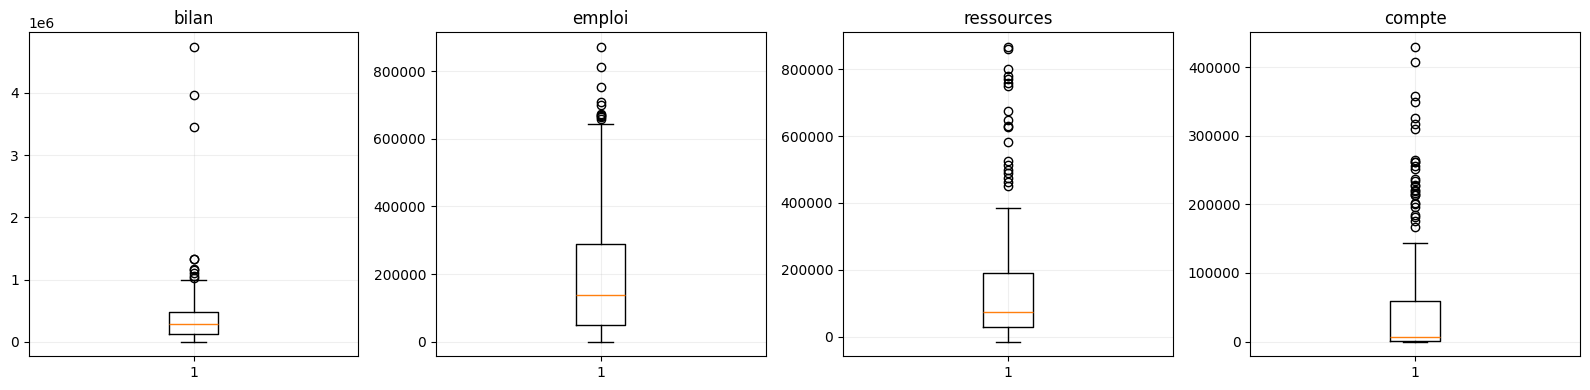

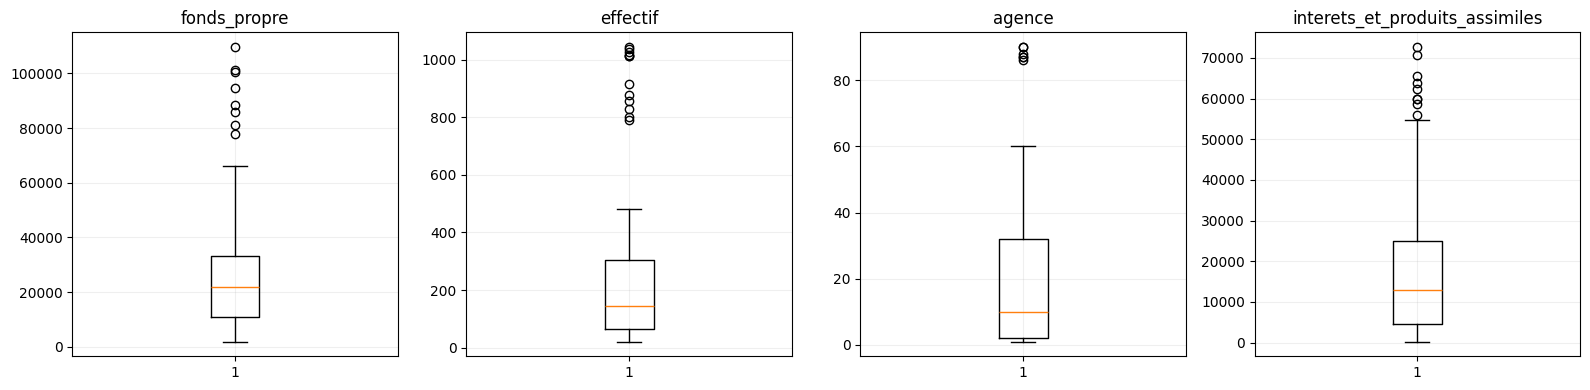

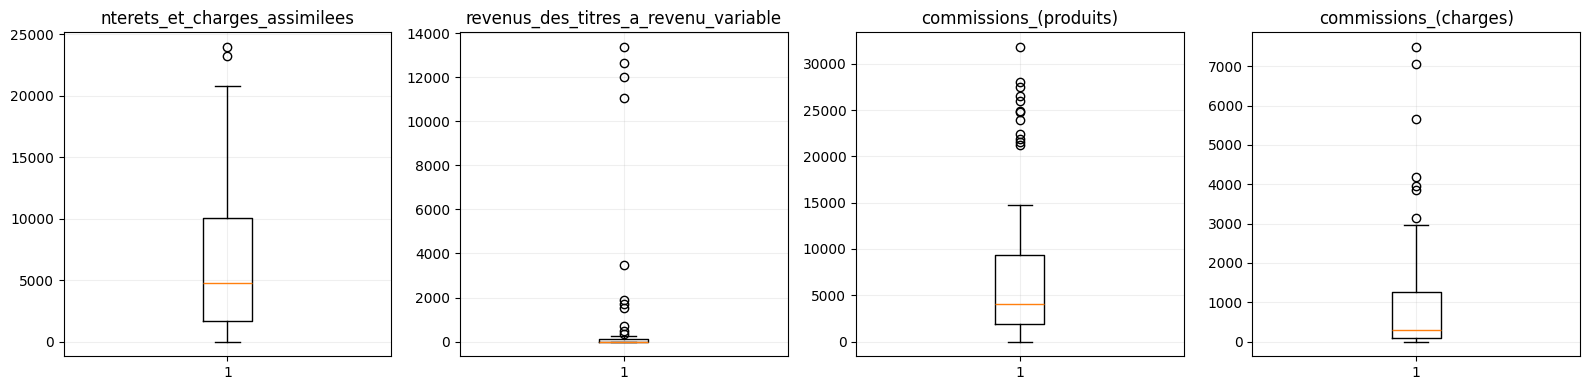

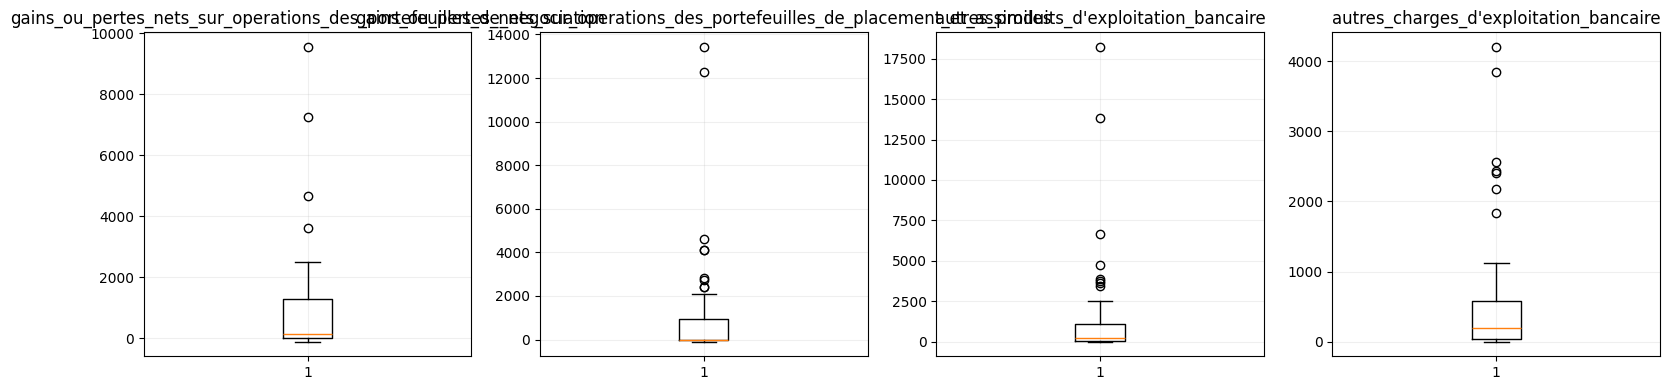

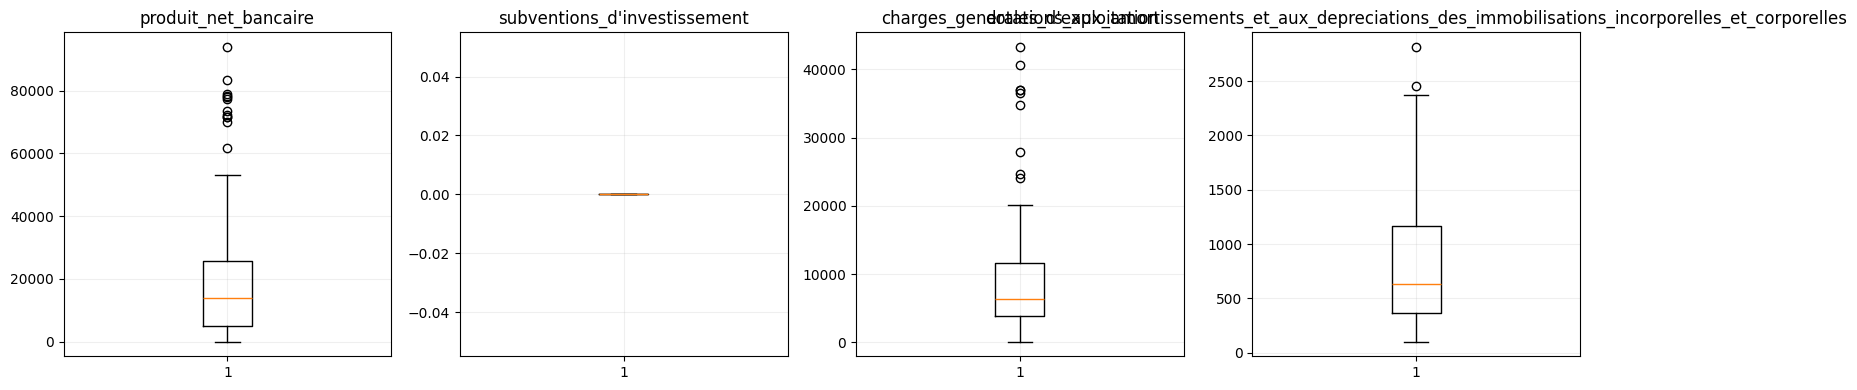

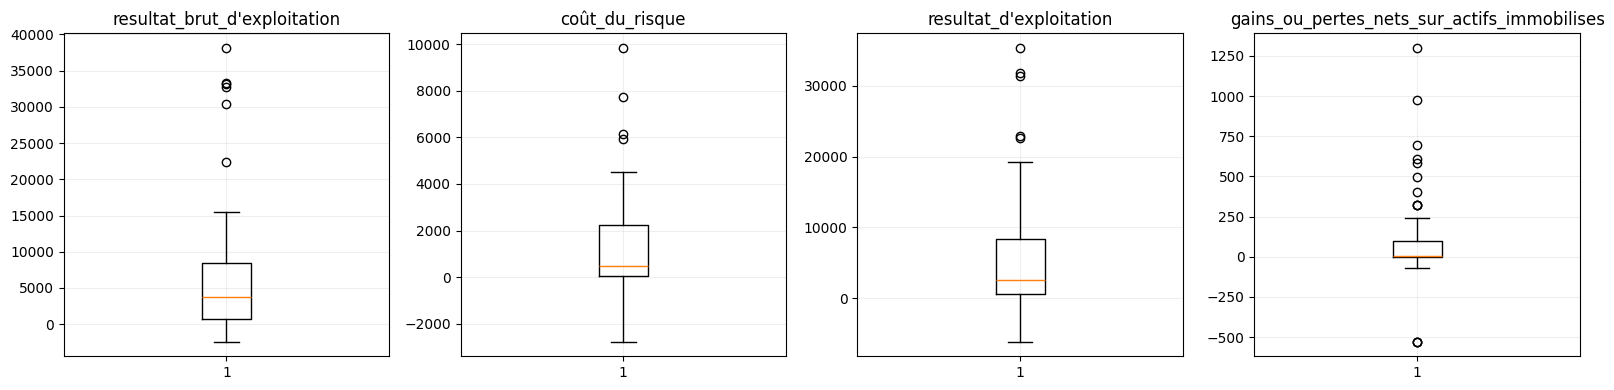

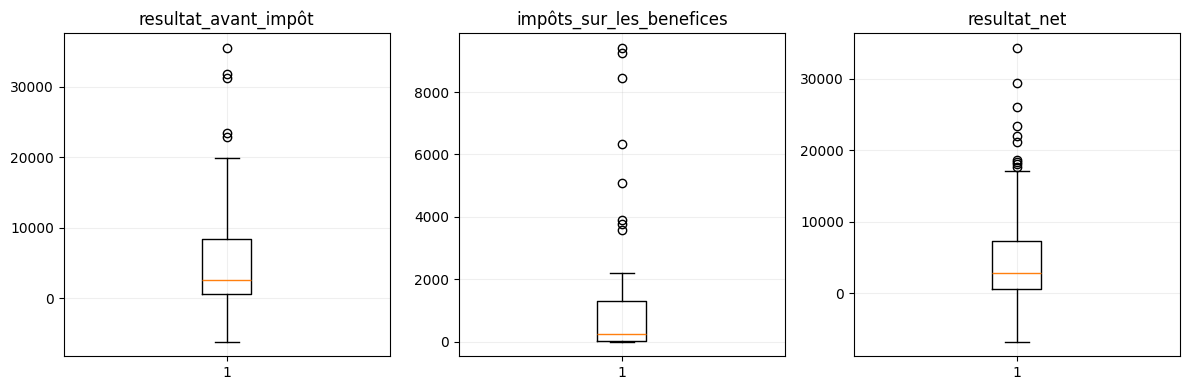

In [4]:
numeric_missing_cols = []
for c in missing_dict.keys():
    if c in df_raw.columns:
        s = pd.to_numeric(df_raw[c], errors="coerce")
        if s.notna().sum() > 0:
            numeric_missing_cols.append(c)

all_boxplot_cols = list(dict.fromkeys(selected_cols + numeric_missing_cols))
print(f"Nombre total de colonnes boxplot: {len(all_boxplot_cols)}")

for i in range(0, len(all_boxplot_cols), 4):
    batch = all_boxplot_cols[i:i+4]
    _, _, plotted_cols = plot_boxplots(df_raw, columns=batch, max_cols=4)
    if plotted_cols:
        print("Batch boxplot:", plotted_cols)

<div style="background: #ecfdf5; border-left: 6px solid #10b981; padding: 12px 14px; border-radius: 10px;">
  <h3 style="margin:0; color:#064e3b;">Etape 4 — Transformation</h3>
  <p style="margin:6px 0 0 0; color:#065f46;">Harmonisation, suppression des doublons et nettoyage de la base.</p>
</div>

In [5]:
df_clean, missing_report = transform_clean(df_raw, return_report=True)
n_transformed = len(df_clean) if df_clean is not None else 0

print(f"Lignes apres transformation: {n_transformed}")
if missing_report:
    d = missing_report.get("dedup", {})
    if d:
        print(f"Dedup: {d.get('removed', 0)} doublons supprimes (de {d.get('before', 0)} a {d.get('after', 0)})")

Lignes apres transformation: 183
Dedup: 21 doublons supprimes (de 204 a 183)


<div style="background: #fefce8; border-left: 6px solid #eab308; padding: 12px 14px; border-radius: 10px;">
  <h3 style="margin:0; color:#713f12;">Etape 5 — Imputation</h3>
  <p style="margin:6px 0 0 0; color:#854d0e;">Decision et detail d'imputation par variable (mode, mean, median).</p>
</div>

In [6]:
imputation_rows = []
if missing_report:
    for col, s in sorted(missing_report.items()):
        if col in ("anomalies", "dedup") or not isinstance(s, dict):
            continue
        imputation_rows.append({
            "colonne": col,
            "missing_before": int(s.get("missing_before", 0)),
            "imputed": int(s.get("imputed", 0)),
            "method": s.get("method", "-"),
            "missing_after": int(s.get("missing_before", 0)) - int(s.get("imputed", 0)),
        })

if imputation_rows:
    df_imp = pd.DataFrame(imputation_rows).sort_values(["imputed", "missing_before"], ascending=False).reset_index(drop=True)
    display(df_imp)
else:
    print("Aucune imputation enregistree.")

,colonne,missing_before,imputed,method,missing_after
0,subventions_d'investissement,158,158,mean,0
1,gains_ou_pertes_nets_sur_operations_des_portef...,136,136,median,0
2,autres_charges_d'exploitation_bancaire,131,131,median,0
3,gains_ou_pertes_nets_sur_operations_des_portef...,131,131,median,0
4,impôts_sur_les_benefices,122,122,median,0
5,autres_produits_d'exploitation_bancaire,121,121,median,0
6,coût_du_risque,121,121,median,0
7,charges_generales_d'exploitation,118,118,median,0
8,dotations_aux_amortissements_et_aux_depreciati...,118,118,median,0
9,resultat_avant_impôt,117,117,median,0


<div style="background: #fff7ed; border-left: 6px solid #f97316; padding: 12px 14px; border-radius: 10px;">
  <h3 style="margin:0; color:#7c2d12;">Etape 6 — Validation avant Load</h3>
  <p style="margin:6px 0 0 0; color:#9a3412;">Apercu final du dataset transforme et verification des manquants restants.</p>
</div>

In [7]:
display(df_clean.head(20))

missing_after_global = int(df_clean.isna().sum().sum()) if df_clean is not None else -1
print(f"Valeurs manquantes restantes (global): {missing_after_global}")
print("Colonnes finales:", list(df_clean.columns))

,Sigle,Goupe_Bancaire,ANNEE,emploi,BILAN,ressources,fonds_propres,effectif,agence,compte,...,charges_generales_d'exploitation,dotations_aux_amortissements_et_aux_depreciations_des_immobilisations_incorporelles_et_corporelles,resultat_brut,coût_du_risque,resultat_d'exploitation,gains_ou_pertes_nets_sur_actifs_immobilises,resultat_avant_impôt,impôts_sur_les_benefices,resultat_net,source
0,BAS,Groupes Continentaux,2019,247812.0,372383.0,189126.0,30994.0,236.0,21.0,73209.0,...,11665.0,805.0,4934.0,199.0,4735.0,3.0,4738.0,5.0,4733.0,excel
1,BAS,Groupes Continentaux,2018,224452.0,325682.0,159065.0,26261.0,228.0,10.0,58765.0,...,10897.0,814.0,3915.0,2377.0,1538.0,2.0,1540.0,5.0,1535.0,excel
2,BAS,Groupes Continentaux,2017,189376.0,341998.0,194008.0,10743.0,213.0,18.0,71197.0,...,8737.0,1079.0,4102.0,2369.0,1733.0,34.0,1767.0,5.0,1762.0,excel
3,BAS,Groupes Continentaux,2015,166775.0,297374.0,162739.0,10437.0,206.0,19.0,47494.0,...,10897.0,814.0,4102.0,2369.0,1733.0,3.0,1767.0,5.0,1762.0,excel
4,BAS,Groupes Continentaux,2016,173612.0,318603.0,153838.0,4513.0,210.0,19.0,60651.0,...,10897.0,814.0,4102.0,2369.0,1733.0,3.0,1767.0,5.0,1762.0,excel
5,BAS,Groupes Continentaux,2020,276934.0,408458.0,204057.0,10743.0,236.0,21.0,99415.0,...,10897.0,814.0,4102.0,2369.0,1733.0,3.0,1767.0,5.0,1762.0,excel
6,BCIM,Groupes Règionaux,2019,9911.0,25730.0,18088.0,5502.0,25.0,2.0,542.0,...,1186.0,368.0,78.0,116.0,-38.0,10.0,-38.0,600.0,-38.0,excel
7,BCIM,Groupes Règionaux,2018,13616.0,32353.0,17443.0,5731.0,26.0,2.0,463.0,...,1250.0,338.0,164.0,-27.0,191.0,10.0,191.0,600.0,191.0,excel
8,BCIM,Groupes Règionaux,2017,14325.0,35673.0,22239.0,5629.0,25.0,2.0,417.0,...,1066.0,352.0,637.0,-75.0,712.0,10.0,712.0,600.0,712.0,excel
9,BCIM,Groupes Règionaux,2015,515.0,5869.0,3551.0,1891.0,25.0,1.0,248.0,...,1186.0,352.0,164.0,-27.0,191.0,10.0,191.0,600.0,191.0,excel


Valeurs manquantes restantes (global): 0
Colonnes finales: ['Sigle', 'Goupe_Bancaire', 'ANNEE', 'emploi', 'BILAN', 'ressources', 'fonds_propres', 'effectif', 'agence', 'compte', 'interets_produits', 'nterets_et_charges_assimilees', 'revenus_des_titres_a_revenu_variable', 'commissions_produits', 'commissions_charges', 'gains_ou_pertes_nets_sur_operations_des_portefeuilles_de_negociation', 'gains_ou_pertes_nets_sur_operations_des_portefeuilles_de_placement_et_assimiles', "autres_produits_d'exploitation_bancaire", "autres_charges_d'exploitation_bancaire", 'produit_net_bancaire', "subventions_d'investissement", "charges_generales_d'exploitation", 'dotations_aux_amortissements_et_aux_depreciations_des_immobilisations_incorporelles_et_corporelles', 'resultat_brut', 'coût_du_risque', "resultat_d'exploitation", 'gains_ou_pertes_nets_sur_actifs_immobilises', 'resultat_avant_impôt', 'impôts_sur_les_benefices', 'resultat_net', 'source']


<div style="background: #f5f3ff; border-left: 6px solid #8b5cf6; padding: 12px 14px; border-radius: 10px;">
  <h3 style="margin:0; color:#4c1d95;">Etape 7 — Load</h3>
  <p style="margin:6px 0 0 0; color:#5b21b6;">Chargement des donnees nettoyees vers <b>bank_prod.prod</b>.</p>
</div>

In [8]:
n_loaded = load_to_prod(df_clean, client=client)
print(f"Load : {n_loaded} documents écrits ({MONGO_COLLECTION_BANQUES_PROD})")

Load : 183 documents écrits (prod)


<div style="background: #f8fafc; border-left: 6px solid #334155; padding: 12px 14px; border-radius: 10px;">
  <h3 style="margin:0; color:#0f172a;">Etape 8 — Verification finale MongoDB</h3>
  <p style="margin:6px 0 0 0; color:#334155;">Controle final sur <b>bank_prod.prod</b>: nombre de documents, doublons et colonnes cles.</p>
</div>

In [9]:
import pandas as pd
from pymongo import MongoClient

_verif_client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
db = _verif_client[MONGO_DB_NAME_PROD]
coll_prod = db[MONGO_COLLECTION_BANQUES_PROD]
docs = list(coll_prod.find({}))
df_prod = pd.DataFrame(docs)
if "_id" in df_prod.columns:
    df_prod = df_prod.drop(columns=["_id"])
n_in_db = len(df_prod)
_verif_client.close()

dup = df_prod.duplicated(subset=["sigle", "annee"]).sum() if "sigle" in df_prod.columns and "annee" in df_prod.columns else -1
ok_no_dup = dup == 0
cols_ok = "sigle" in df_prod.columns and "annee" in df_prod.columns and "bilan" in df_prod.columns

print("Verification (donnees lues depuis bank_prod.prod) :")
print(f"  Nombre de documents en base : {n_in_db}")
print(f"  Doublons (sigle, annee) : {dup} -> {'OK' if ok_no_dup else 'ANOMALIE'}")
print(f"  Colonnes cles (sigle, annee, bilan) : {'OK' if cols_ok else 'MANQUANT'}")
print(f"  Colonnes presentes : {list(df_prod.columns)}")
print("\nApercu (5 premiers enregistrements) :")
display(df_prod.head(160))

Verification (donnees lues depuis bank_prod.prod) :
  Nombre de documents en base : 183
  Doublons (sigle, annee) : 0 -> OK
  Colonnes cles (sigle, annee, bilan) : OK
  Colonnes presentes : ['sigle', 'groupe_bancaire', 'annee', 'emploi', 'bilan', 'ressources', 'fonds_propres', 'effectif', 'agence', 'compte', 'interets_produits', 'nterets_et_charges_assimilees', 'revenus_des_titres_a_revenu_variable', 'commissions_produits', 'commissions_charges', 'gains_ou_pertes_nets_sur_operations_des_portefeuilles_de_negociation', 'gains_ou_pertes_nets_sur_operations_des_portefeuilles_de_placement_et_assimiles', "autres_produits_d'exploitation_bancaire", "autres_charges_d'exploitation_bancaire", 'produit_net_bancaire', "subventions_d'investissement", "charges_generales_d'exploitation", 'dotations_aux_amortissements_et_aux_depreciations_des_immobilisations_incorporelles_et_corporelles', 'resultat_brut', 'coût_du_risque', "resultat_d'exploitation", 'gains_ou_pertes_nets_sur_actifs_immobilises', 'resul

,sigle,groupe_bancaire,annee,emploi,bilan,ressources,fonds_propres,effectif,agence,compte,...,charges_generales_d'exploitation,dotations_aux_amortissements_et_aux_depreciations_des_immobilisations_incorporelles_et_corporelles,resultat_brut,coût_du_risque,resultat_d'exploitation,gains_ou_pertes_nets_sur_actifs_immobilises,resultat_avant_impôt,impôts_sur_les_benefices,resultat_net,source
0,BAS,Groupes Continentaux,2019,247812.0,372383.0,189126.0,30994.0,236.0,21.0,73209.0,...,11665.0,805.0,4934.0,199.0,4735.0,3.0,4738.0,5.0,4733.0,excel
1,BAS,Groupes Continentaux,2018,224452.0,325682.0,159065.0,26261.0,228.0,10.0,58765.0,...,10897.0,814.0,3915.0,2377.0,1538.0,2.0,1540.0,5.0,1535.0,excel
2,BAS,Groupes Continentaux,2017,189376.0,341998.0,194008.0,10743.0,213.0,18.0,71197.0,...,8737.0,1079.0,4102.0,2369.0,1733.0,34.0,1767.0,5.0,1762.0,excel
3,BAS,Groupes Continentaux,2015,166775.0,297374.0,162739.0,10437.0,206.0,19.0,47494.0,...,10897.0,814.0,4102.0,2369.0,1733.0,3.0,1767.0,5.0,1762.0,excel
4,BAS,Groupes Continentaux,2016,173612.0,318603.0,153838.0,4513.0,210.0,19.0,60651.0,...,10897.0,814.0,4102.0,2369.0,1733.0,3.0,1767.0,5.0,1762.0,excel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,ECOBANK,Groupes Continentaux,2022,352174.0,844547.0,52922.0,36623.0,377.5,34.0,6103.0,...,24600.0,2342.0,14971.0,2284.0,8816.0,0.0,8911.0,5.0,12307.0,bceao_pdf
156,ORABANK,Groupes Continentaux,2021,258008.0,489722.0,20722.0,10199.0,120.0,8.5,3139.0,...,7247.0,446.0,3705.0,1099.0,2606.0,55.0,2604.0,600.0,5363.0,bceao_pdf
157,ORABANK,Groupes Continentaux,2022,367558.0,641156.0,37030.0,10199.0,120.0,8.5,5386.0,...,7247.0,446.0,3705.0,1099.0,2606.0,3.0,2604.0,600.0,11307.0,bceao_pdf
158,BOA,Groupes Continentaux,2021,279572.0,561588.0,46551.0,34093.0,330.0,57.0,5794.0,...,14205.0,1905.0,10609.0,-315.0,10121.0,40.0,10065.0,759.0,7667.0,bceao_pdf
